**Loan Default Prediction Dataset ANALYSIS**

In [ ]:
# --- Import Necessary Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN


In [5]:
df = pd.read_csv("D:\creditpathAI\datasets\Loan_default.csv")
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [7]:
df.shape


(255347, 18)

In [8]:
# Display basic information about the dataset
print("--- First 5 Rows ---")
print(df.head())

print("\n--- Data Types and Non-Null Counts ---")
df.info()

# Get a summary of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\n--- Percentage of Missing Values ---")
print(missing_percentage)

--- First 5 Rows ---
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   

In [12]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,1.494421,1.500096,0.999918,0.500014,0.500268,2.000501,0.500108,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,1.118826,1.117358,0.816051,0.500001,0.500001,1.412723,0.500001,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,2.000000,2.000000,2.000000,1.000000,1.000000,3.000000,1.000000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,3.000000,3.000000,2.000000,1.000000,1.000000,4.000000,1.000000,1.000000


In [13]:
df.isnull().sum()

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [15]:
df.nunique()

Age                   52
Income            114620
LoanAmount        158729
CreditScore          550
MonthsEmployed       120
NumCreditLines         4
InterestRate        2301
LoanTerm               5
DTIRatio              81
Education              4
EmploymentType         4
MaritalStatus          3
HasMortgage            2
HasDependents          2
LoanPurpose            5
HasCoSigner            2
Default                2
dtype: int64

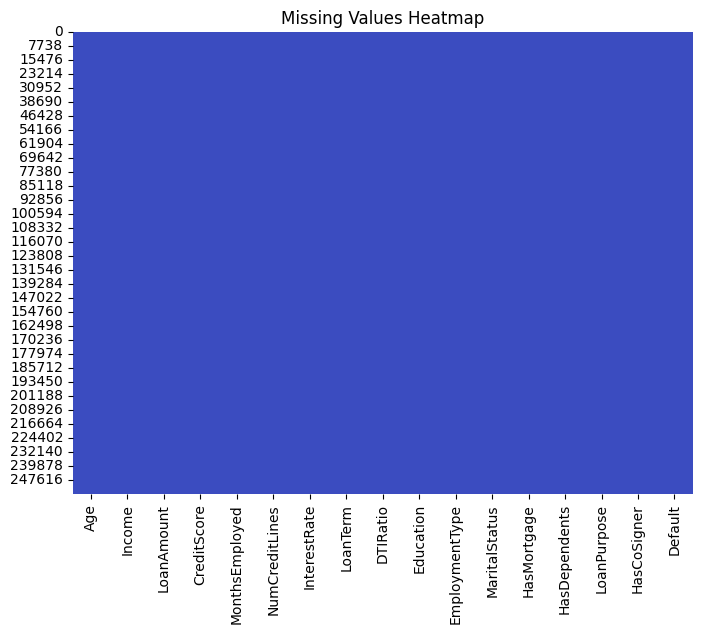

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap="coolwarm")
plt.title("Missing Values Heatmap")
plt.show()

In [17]:
# Fill categorical columns with mode
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numeric columns with median
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())


In [18]:
target = 'Default'
numerical_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
                  'MonthsEmployed', 'NumCreditLines', 'InterestRate',
                  'LoanTerm', 'DTIRatio']

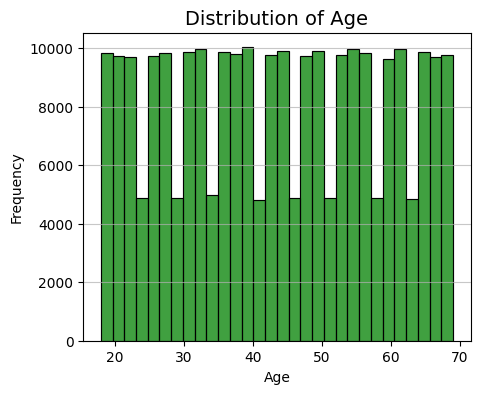

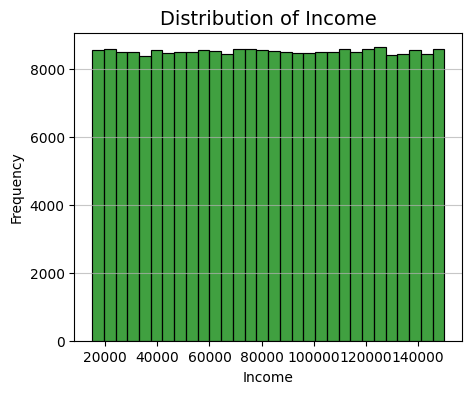

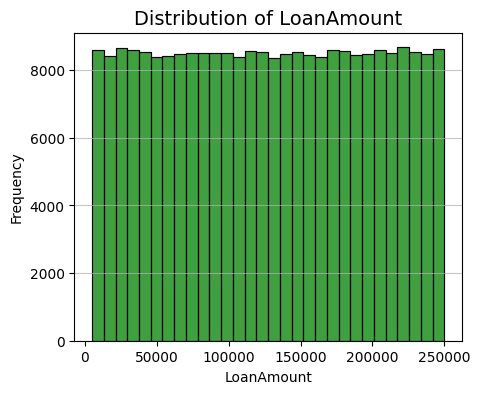

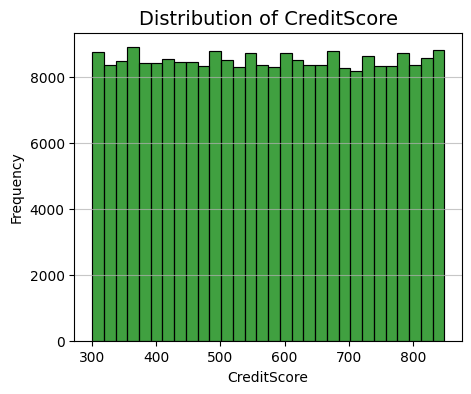

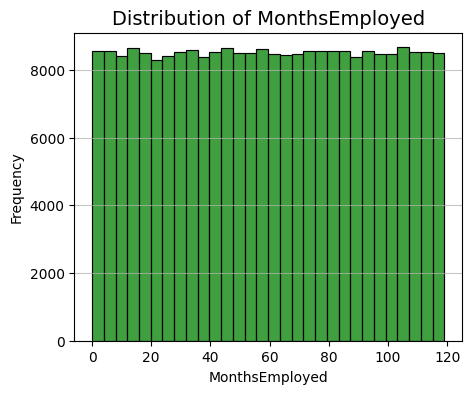

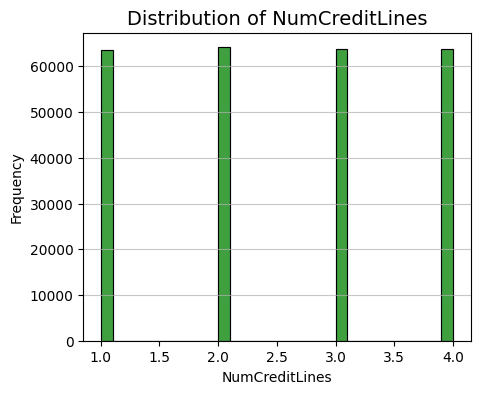

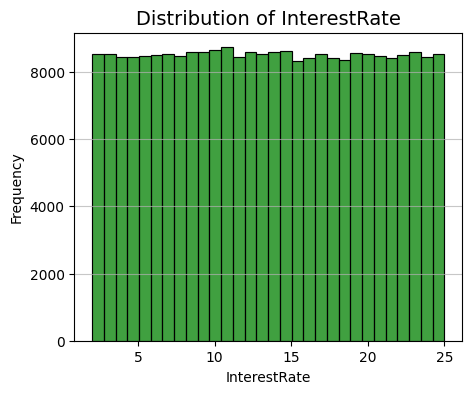

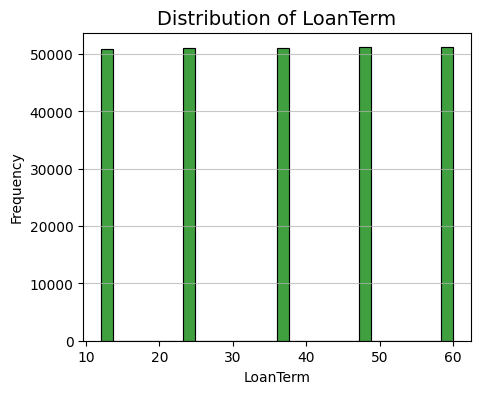

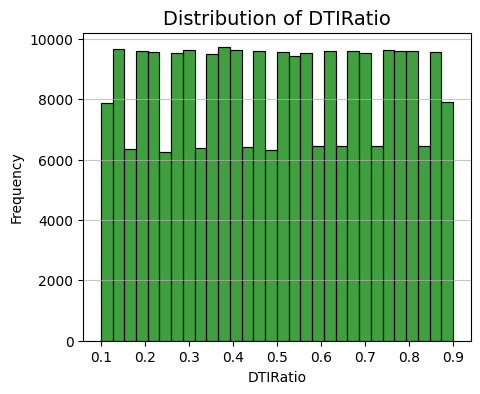

In [21]:
for col in numerical_cols:
    plt.figure(figsize=(5, 4))
    sns.histplot(df[col], bins=30, color='green')
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='-', alpha=0.7)
    plt.show()

In [22]:
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus',
                    'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

In [26]:
cat_cols = df.select_dtypes(include=["object"]).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

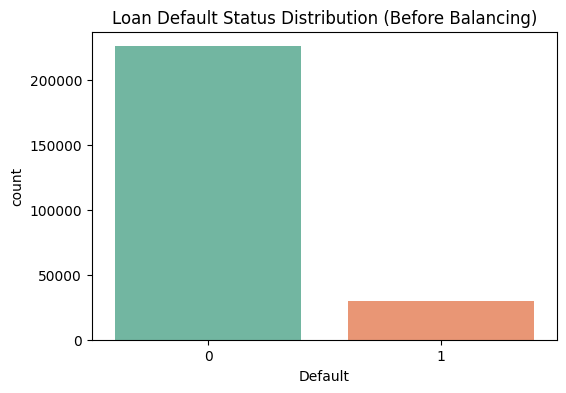

Default
0    225694
1     29653
Name: count, dtype: int64

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="Default", data=df, palette="Set2")
plt.title("Loan Default Status Distribution (Before Balancing)")
plt.show()

df["Default"].value_counts()

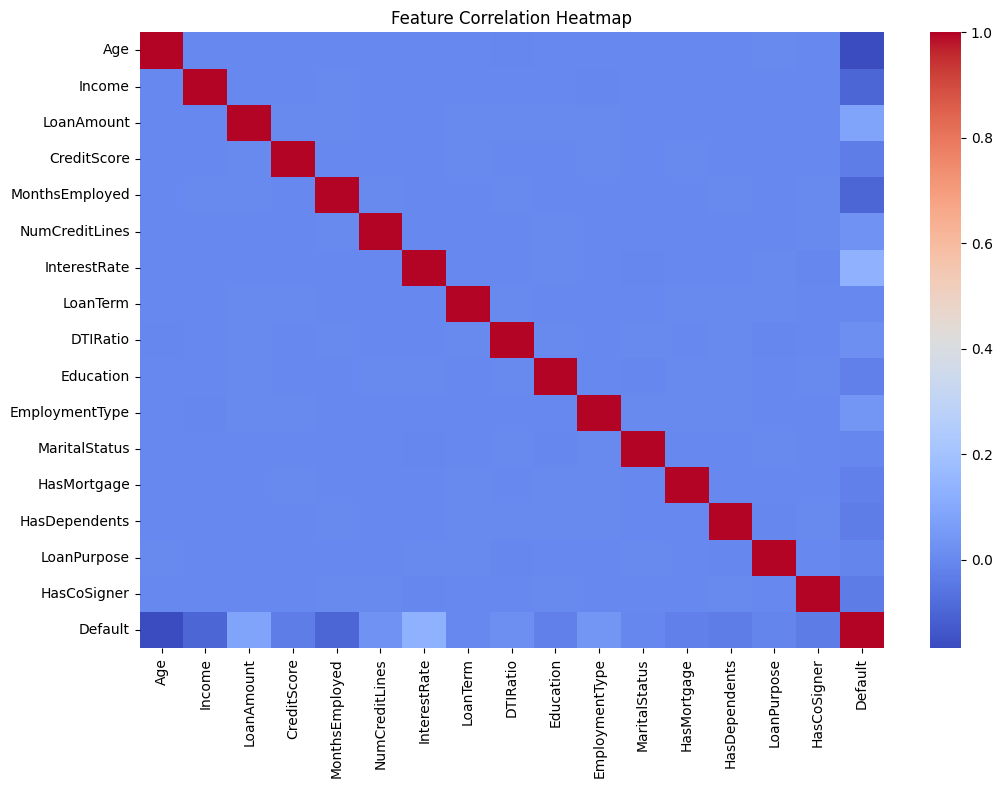

In [48]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [28]:
X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [36]:
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)

print("Before balancing:\n", y_train.value_counts())
print("\nAfter balancing:\n", y_resampled.value_counts())


Before balancing:
 Default
0    180555
1     23722
Name: count, dtype: int64

After balancing:
 Default
1    179608
0    103087
Name: count, dtype: int64


In [42]:
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score

#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB


--- Evaluation for Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.60      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.74      0.51      0.50     51070
weighted avg       0.85      0.89      0.84     51070

Accuracy Score: 0.8851
ROC-AUC Score: 0.7497


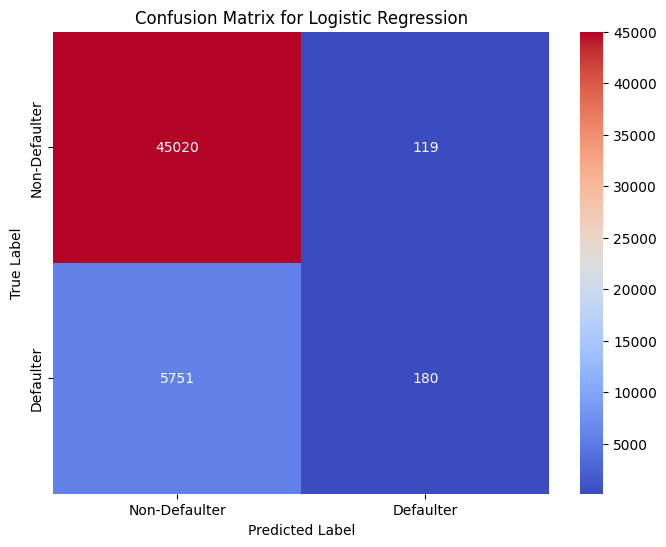

--------------------------------------------------

--- Evaluation for Decision Tree ---
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45139
           1       0.19      0.22      0.21      5931

    accuracy                           0.80     51070
   macro avg       0.54      0.55      0.55     51070
weighted avg       0.81      0.80      0.81     51070

Accuracy Score: 0.8015
ROC-AUC Score: 0.5495


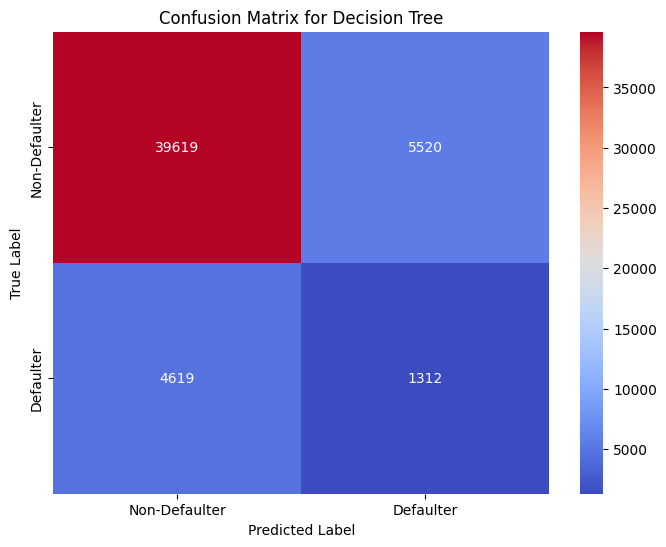

--------------------------------------------------

--- Evaluation for Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.59      0.04      0.08      5931

    accuracy                           0.89     51070
   macro avg       0.74      0.52      0.51     51070
weighted avg       0.85      0.89      0.84     51070

Accuracy Score: 0.8854
ROC-AUC Score: 0.7353


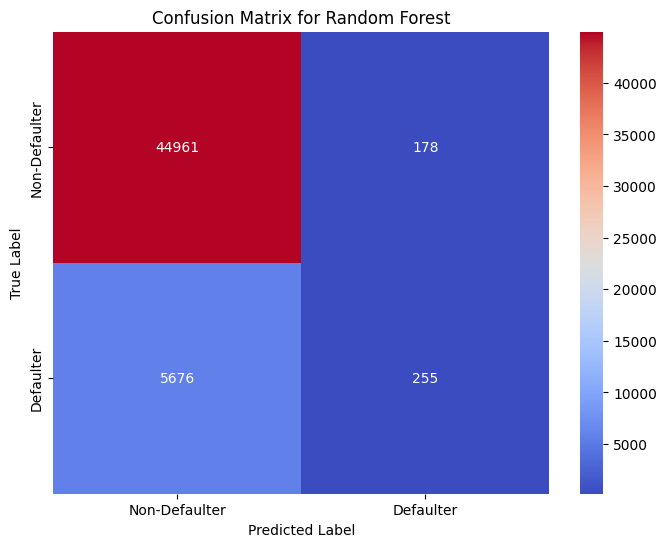

--------------------------------------------------

--- Evaluation for XGBoost ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.53      0.08      0.14      5931

    accuracy                           0.88     51070
   macro avg       0.71      0.54      0.54     51070
weighted avg       0.85      0.88      0.85     51070

Accuracy Score: 0.8849
ROC-AUC Score: 0.7430


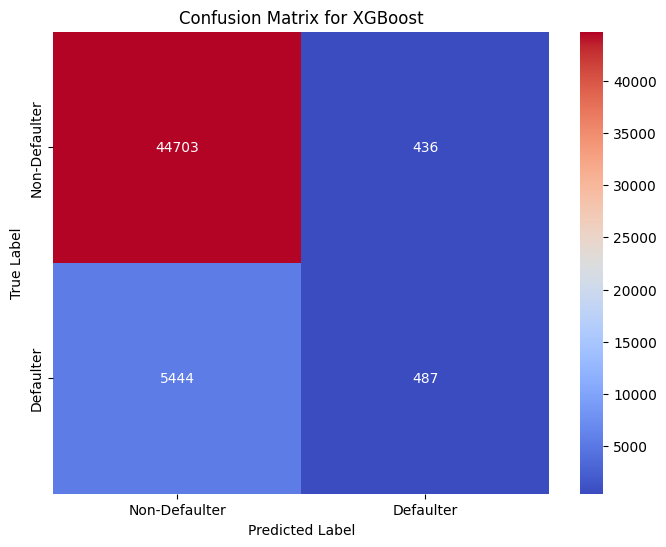

--------------------------------------------------


In [46]:
# --- Define Models ---
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# --- Dictionary to store results ---
results = {}

# --- Train and Evaluate Each Model ---
for name, model in models.items():
    # --- THIS IS THE FIX: Fit the model before predicting ---
    model.fit(X_train, y_train)

    print(f"\n--- Evaluation for {name} ---")

    # Make predictions on the test set
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Print Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Get accuracy and AUC score
    acc = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"Accuracy Score: {acc:.4f}")
    print(f"ROC-AUC Score: {auc_score:.4f}")

    # Store results
    results[name] = {"Accuracy": acc, "AUC_Score": auc_score}

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Non-Defaulter', 'Defaulter'],
                yticklabels=['Non-Defaulter', 'Defaulter'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    print("-" * 50)


--- Final Model Comparison ---
                     Accuracy  AUC_Score
Random Forest        0.885373   0.735308
Logistic Regression  0.885060   0.749717
XGBoost              0.884864   0.742976
Decision Tree        0.801469   0.549461


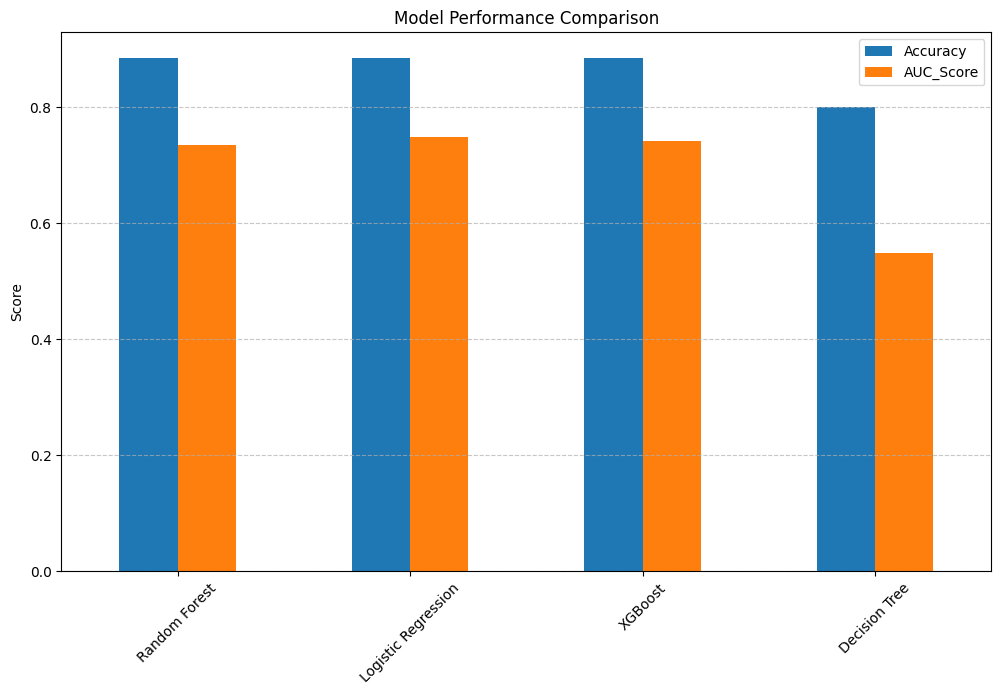

In [47]:
# --- Final Comparison ---
results_df = pd.DataFrame(results).T # Transpose the dataframe for better viewing
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\n--- Final Model Comparison ---")
print(results_df)

# Plot the results
results_df.plot(kind='bar', figsize=(12, 7))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()